In [5]:
from pathlib import Path
import sys

# Add parent directory to path for imports
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from matplotlib.ticker import EngFormatter
fmt = EngFormatter(unit="m", places=None, sep=" ")
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

from src.JUDITHDataset import JUDITHDataset

from IPython.display import HTML

# Helpers

In [6]:
# style for pandas table
def center_multiindex_columns(styler):
    # Your existing centering rules
    styler.set_table_styles([
        dict(selector="th.col_heading.level0", props=[("text-align", "center")]),
        dict(selector="th.col_heading.level1", props=[("text-align", "center")]),
        dict(selector="td", props=[("text-align", "center")]),
    ], overwrite=False)

    # NEW rules to allow horizontal scrolling
    styler.set_table_styles([
        # Let the table take its natural width (so overflow can happen)
        dict(selector="table", props=[("width", "auto")]),

        # Prevent wrapping — important for multi-column layouts
        dict(selector="th, td", props=[("white-space", "nowrap")]),
    ], overwrite=False)

    return styler


def add_separators_after(styler, cols, color="#444", width="2px"):
    """
    Add a vertical separator AFTER each column index in `cols`.

    Example: cols=[2, 5] draws a line after col2 and col5.
    """
    styles = []
    for c in cols:
        selector = f".col{c}"
        styles.append(
            dict(
                selector=selector,
                props=[("border-right", f"{width} solid {color}")]
            )
        )
    return styler.set_table_styles(styles, overwrite=False)


def display_styled(df, width="100%", cols=None, max_height=None):
    df = df.style.pipe(center_multiindex_columns)
    if cols is not None:
        df = df.pipe(add_separators_after, cols=cols)
    html = df.to_html(escape=False)

    # Wrapper stays the same but now scrolling will appear
    style = (
        f"max-width:{width}; "
        f"overflow-x:auto; "
        f"border:1px solid #ccc; "
        f"padding:4px;"
    )
    if max_height:
        style += f" max-height:{max_height}; overflow-y:auto;"

    return HTML(f'<div style="{style}">{html}</div>')

# Data

In [7]:
dataset = JUDITHDataset(preload=True)
print('Metadata keys:', dataset.metadata.keys())

Metadata keys: dict_keys(['filename', 'material', 'loadtype', 'label', 'base_temp', 'flux', 'scale', 'detector', 'resolution'])


### Image data

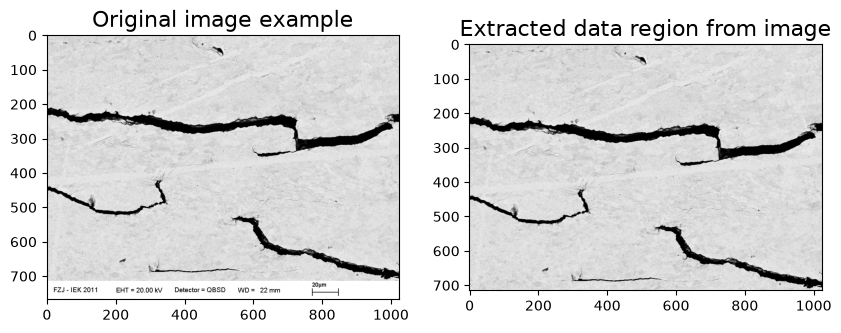

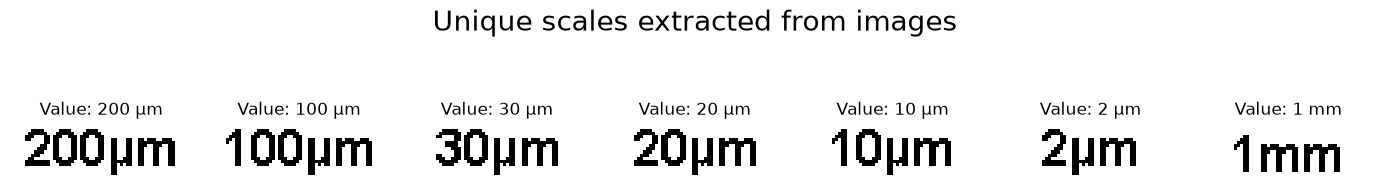

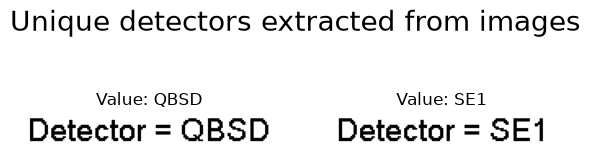

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(dataset.images[0], cmap='gray')
axes[0].set_title('Original image example', fontsize=16)
# axes[0].axis('off')
axes[1].imshow(dataset.data[0], cmap='gray')
axes[1].set_title('Extracted data region from image', fontsize=16)
# axes[1].axis('off')
plt.show()


unique_scales, unique_indices = np.unique(dataset.unique_visual['scale'], axis=0, return_index=True)
fig, axes = plt.subplots(1, len(unique_scales), figsize=(len(unique_scales)*2, 3))
for ax, sc, idx in zip(axes, unique_scales, unique_indices):
    ax.axis('off')
    ax.imshow(sc, cmap='gray')
    ax.set_title(f'Value: {fmt(dataset.scales[idx])}')
    ax.axis('off')
fig.tight_layout(rect=[0,0,1,1])
fig.suptitle('Unique scales extracted from images', fontsize=20)
plt.show()


unique_detectors, unique_indices = np.unique(dataset.unique_visual['detector'], axis=0, return_index=True)
fig, axes = plt.subplots(1, len(unique_detectors), figsize=(len(unique_detectors)*3, 2.5))
for ax, det, idx in zip(axes, unique_detectors, unique_indices):
    ax.axis('off')
    ax.imshow(det, cmap='gray')
    ax.set_title(f'Value: {dataset.detectors[idx]}')
fig.tight_layout(rect=[0,0,1,1])
fig.suptitle('Unique detectors extracted from images', fontsize=20)
plt.show()

### Data summary

Total images:     418
Image shape:      (768, 1024)
Data shape:       (715, 1024)
Num experiments:  114
Num materials:    5 ['M192 - W-UHP' 'M193 - WVMW' 'M194 - WTa1' 'M195 - WTa5' 'M196 - pure W']
Num load types:   3 ['longitudinal' 'recrystalised' 'transversal']
Num detectors:    2 ['QBSD' 'SE1']
Num scales:       7 [2.e-06 1.e-05 2.e-05 3.e-05 1.e-04 2.e-04 1.e-03]
Num resolutions:  45
Num resolutions < 5.e-6:  14 ['2.0e-08', '5.2e-08', '1.0e-07', '1.0e-07', '1.3e-07', '1.3e-07', '1.7e-07', '1.7e-07', '2.6e-07', '3.4e-07', '5.2e-07', '1.0e-06', '1.0e-06', '1.7e-06']
Num resolutions >= 5.e-6:  31 ['5.2e-06', '5.2e-06', '5.2e-06', '5.3e-06', '5.3e-06', '5.3e-06', '5.3e-06', '5.4e-06', '5.4e-06', '5.4e-06', '5.5e-06', '5.5e-06', '5.6e-06', '5.7e-06', '5.7e-06', '5.7e-06', '5.8e-06', '5.8e-06', '5.8e-06', '5.9e-06', '5.9e-06', '6.0e-06', '6.0e-06', '6.1e-06', '6.1e-06', '6.2e-06', '6.2e-06', '6.3e-06', '6.3e-06', '6.3e-06', '6.4e-06']
Num images with resolution < 5.e-6:  301


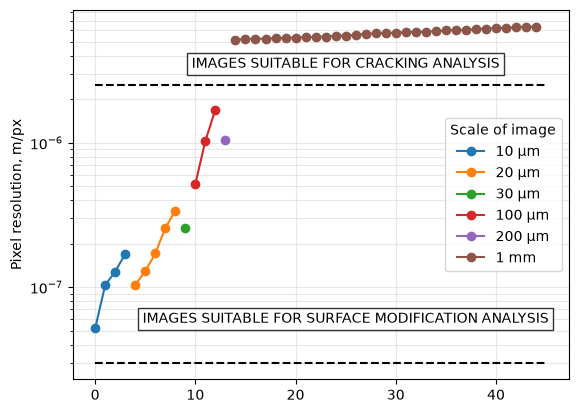

In [9]:
print("Total images:    ", len(dataset))
print("Image shape:     ", dataset.images[0].shape)
print("Data shape:      ", dataset.data[0].shape)
print("Num experiments: ", len(dataset.unique_meta['label']))
print("Num materials:   ", len(dataset.unique_meta['material']), dataset.unique_meta['material'])
print("Num load types:  ", len(dataset.unique_meta['loadtype']), dataset.unique_meta['loadtype'])
print("Num detectors:   ", len(dataset.unique_meta['detector']), dataset.unique_meta['detector'])
print("Num scales:      ", len(dataset.unique_meta['scale']), dataset.unique_meta['scale'])
print("Num resolutions: ", len(dataset.unique_meta['resolution']))
print("Num resolutions < 5.e-6: ",  len(dataset.unique_meta['resolution'][dataset.unique_meta['resolution'] < 5.e-6]), [f'{r:.1e}' for r in dataset.unique_meta['resolution'][dataset.unique_meta['resolution'] < 5.e-6]])
print("Num resolutions >= 5.e-6: ", len(dataset.unique_meta['resolution'][dataset.unique_meta['resolution'] >= 5.e-6]), [f'{r:.1e}' for r in dataset.unique_meta['resolution'][dataset.unique_meta['resolution'] >= 5.e-6]])
print("Num images with resolution < 5.e-6: ", np.sum(dataset.metadata['resolution'] < 5.e-6))


min_resolution = 3e-8
max_resolution = 2.5e-6
xind = [-1]
for sc in dataset.unique_meta['scale'][dataset.unique_meta['scale']>2e-6]:
    mask = dataset.metadata['scale']==sc
    res_sc  = np.unique(dataset.metadata['resolution'][mask])
    num_res = np.zeros(len(res_sc))
    for i, res in enumerate(res_sc):
        num_res[i] = np.sum(np.logical_and(mask, dataset.metadata['resolution']==res))
    num_res /= num_res.min()
    xind = xind[-1] + np.arange(1,len(res_sc)+1)
    plt.semilogy(xind, res_sc, '-o', label=f"{fmt(sc)}")
    # plt.semilogy(xind, res_sc, '-o', label=f"{sc:.0e} m".replace("e+0", "e+").replace("e-0", "e-"))
plt.hlines([min_resolution, max_resolution], xmin=0, xmax=xind[-1]+1, colors='k', linestyles='dashed')#, label='Resolution filter bounds')
plt.grid(True, which='both', alpha=0.3)
plt.ylabel('Pixel resolution, m/px')
# plt.title("Ordered pixel resolutions for each scale")
plt.legend(loc='right', title='Scale of image')
plt.text(25, 3.5e-6, "IMAGES SUITABLE FOR CRACKING ANALYSIS", ha="center", va="center", bbox=dict(facecolor="white", alpha=0.8, edgecolor="black", pad=3))
plt.text(25, 6e-8, "IMAGES SUITABLE FOR SURFACE MODIFICATION ANALYSIS", ha="center", va="center", bbox=dict(facecolor="white", alpha=0.8, edgecolor="black", pad=3))
plt.show()


display_styled(dataset.summary_table(), width="200%", cols=[1,9], max_height=None)
# print(dataset.summary_table().to_latex())

### Representative Images by Resolution

/tmp/ipykernel_2349188/4092365016.py:43: RuntimeWarning: divide by zero encountered in scalar floor_divide
  shift_y = np.abs(dataset_QBSD.data[img_idx].shape[0] - (num_patches_y+1)*patch_size_pixels) // num_patches_y + 0


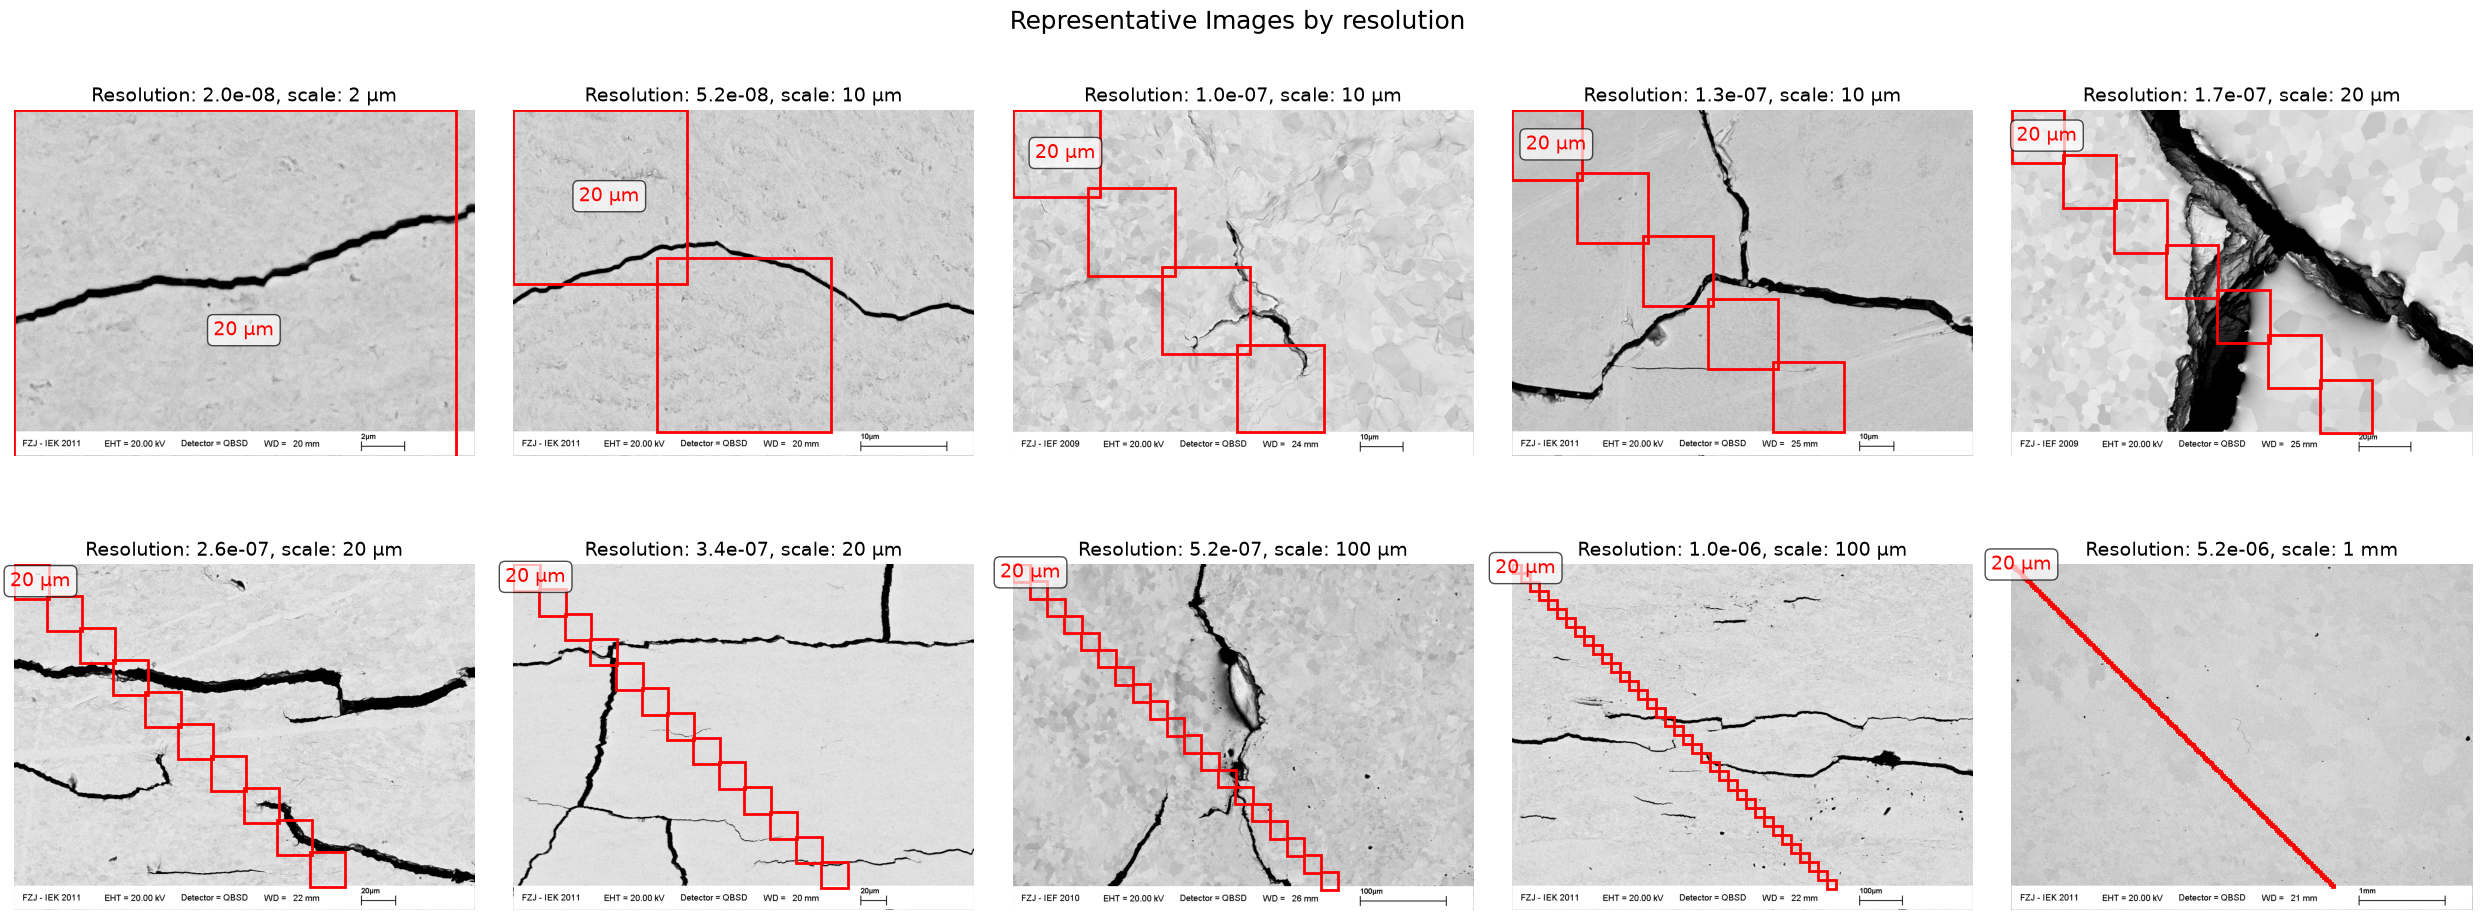

In [14]:
plot_patch = True

# Physical patch size to display (in meters)
patch_size_physical = 20e-6  # 20 micrometer

# images for QBSD detector
dataset_QBSD = dataset.filter_by_metadata(detector='QBSD')

# Get representative resolutions as strings in scientific notation
resolutions_sci = np.array([float(f"{r:.1e}") for r in np.sort(dataset_QBSD.unique_meta['resolution'])])
unique_resolution_str = [f'{ri:.1e}' for ri in resolutions_sci[np.r_[True, np.diff(resolutions_sci) > 0.05 * (resolutions_sci[:-1] + 1e-20)]]]

# Create a grid layout
n_resolutions = len(unique_resolution_str)
n_cols = min(5, n_resolutions)  # max 5 columns
n_rows = int(np.ceil(n_resolutions / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*5))
if n_resolutions == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, resolution in enumerate(unique_resolution_str):
    # Find first image with this resolution
    mask = np.array([f'{ri:.1e}' for ri in dataset_QBSD.metadata['resolution']]) == resolution
    indices = np.where(mask)[0]

    if len(indices) > 0:
        img_idx = indices[0]

        axes[idx].imshow(dataset_QBSD.images[img_idx], cmap='gray')

        # plot patch overlay if enabled
        if plot_patch:
            # Calculate patch size in pixels
            resolution_float  = dataset_QBSD.metadata["resolution"][img_idx]
            patch_size_pixels = int(np.ceil(patch_size_physical / resolution_float))

            num_patches_x = dataset_QBSD.data[img_idx].shape[1] // patch_size_pixels
            num_patches_y = dataset_QBSD.data[img_idx].shape[0] // patch_size_pixels

            shift_x = np.abs(dataset_QBSD.data[img_idx].shape[1] - (num_patches_x+1)*patch_size_pixels) // num_patches_x + 0
            shift_y = np.abs(dataset_QBSD.data[img_idx].shape[0] - (num_patches_y+1)*patch_size_pixels) // num_patches_y + 0

            # Draw patch outline in the upper-left corner
            for pix in range(num_patches_x+1):
                for piy in range(num_patches_y+1):
                    if pix!=piy:
                        continue
                    x0 = pix * patch_size_pixels
                    y0 = piy * patch_size_pixels
                    rect = Rectangle((x0-shift_x*pix, y0-shift_y*piy), patch_size_pixels, patch_size_pixels, linewidth=2, edgecolor='red', facecolor='none', linestyle='-')
                    axes[idx].add_patch(rect)

            # Add label for the patch
            axes[idx].text(20 + patch_size_pixels/2, 20 + patch_size_pixels/2, f'{fmt(patch_size_physical)}',
                        color='red', fontsize=14, ha='center', va='bottom',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

        title_str = f'Resolution: {resolution}, scale: {fmt(dataset_QBSD.metadata["scale"][img_idx])}'
        # if plot_patch:
        #      title_str += f', full patches: {num_patches_x}x{num_patches_y}'
        axes[idx].set_title(title_str, fontsize=14)
        axes[idx].axis('off')

# Hide unused subplots
for idx in range(n_resolutions, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Representative Images by resolution', fontsize=18, y=1.00)
plt.show()


### Representative Patches by Resolution

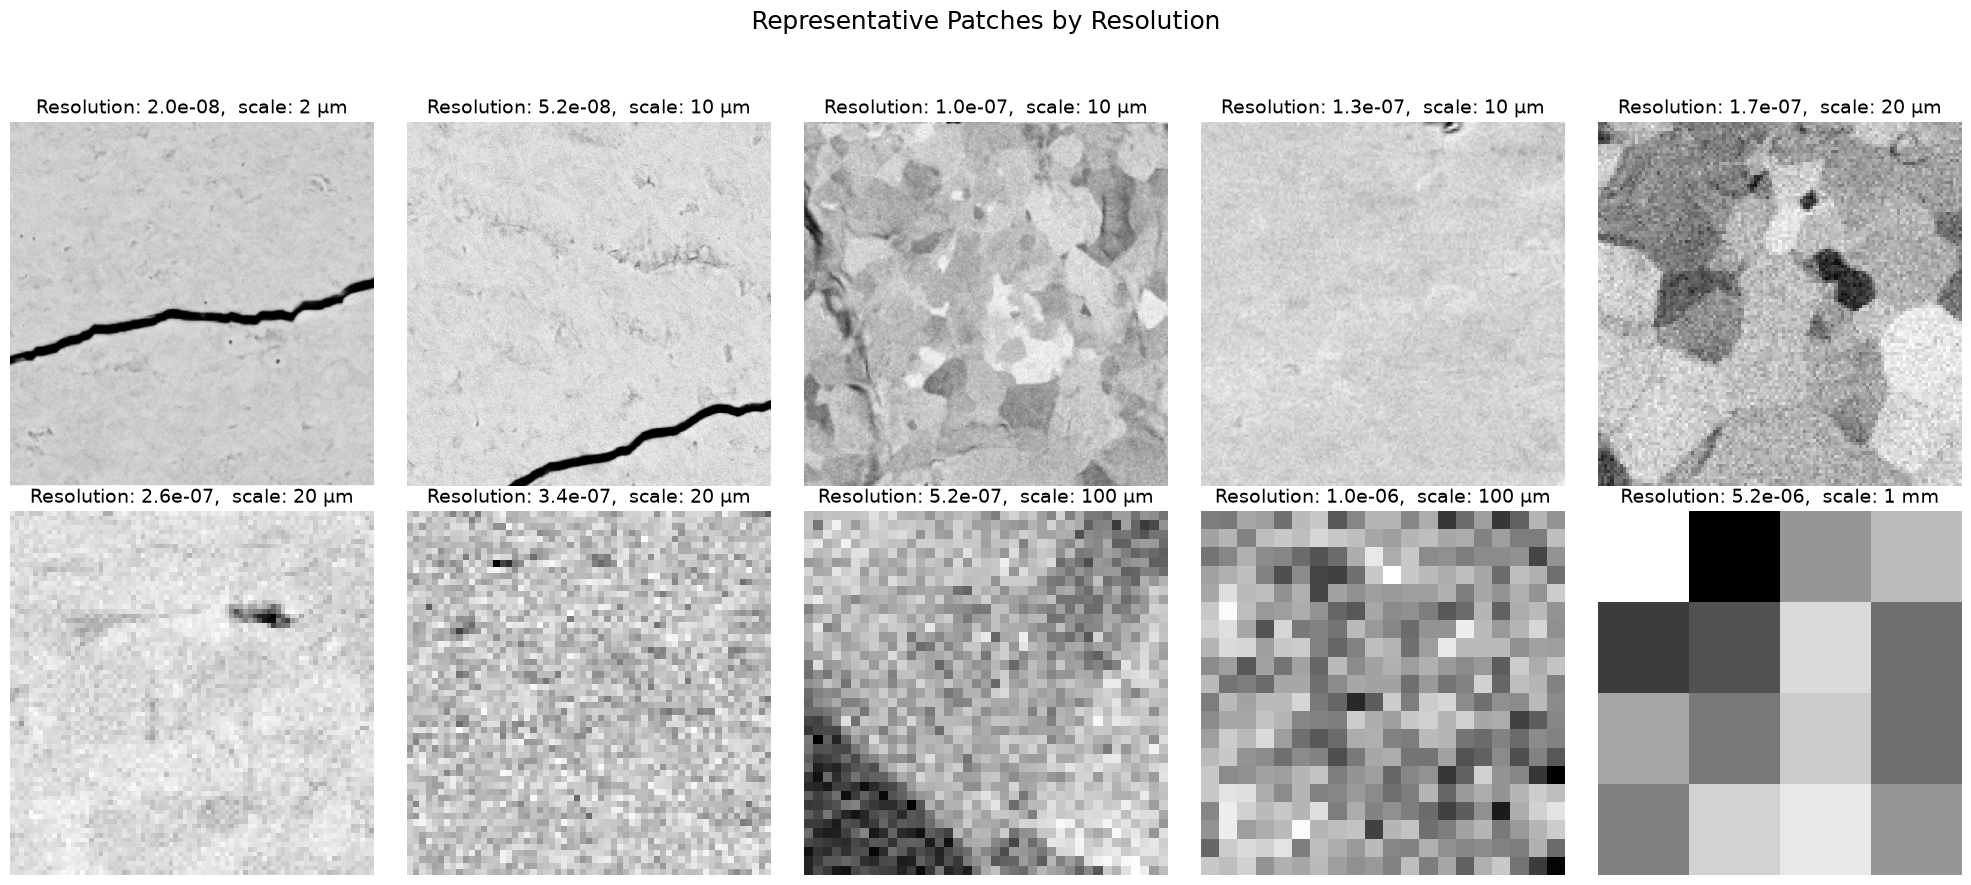

In [11]:
patch_size_physical = 20e-6  # 20 micrometer

# images for QBSD detector
dataset_QBSD = dataset.filter_by_metadata(detector='QBSD')

# Get representative resolutions as strings in scientific notation
resolutions_sci = np.array([float(f"{r:.1e}") for r in np.sort(dataset_QBSD.unique_meta['resolution'])])
unique_resolution_str = [f'{ri:.1e}' for ri in resolutions_sci[np.r_[True, np.diff(resolutions_sci) > 0.05 * (resolutions_sci[:-1] + 1e-20)]]]

# Create a grid layout
n_resolutions = len(unique_resolution_str)
n_cols = min(5, n_resolutions)  # max 5 columns
n_rows = int(np.ceil(n_resolutions / n_cols))


fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
if n_resolutions == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, resolution in enumerate(unique_resolution_str):
    mask = np.array([f"{ri:.1e}" for ri in dataset_QBSD.metadata["resolution"]]) == resolution
    indices = np.where(mask)[0]
    if len(indices) == 0:
        axes[idx].axis("off")
        continue

    img_idx = indices[0]
    img = dataset_QBSD.data[img_idx]
    h, w = img.shape[:2]

    resolution_float = float(dataset_QBSD.metadata["resolution"][img_idx])
    patch_size_pixels = int(np.ceil(patch_size_physical / resolution_float))
    patch_size_pixels = max(1, min(patch_size_pixels, h, w))

    # x0 = max(0, (w - patch_size_pixels) // 2)
    # y0 = max(0, (h - patch_size_pixels) // 2)
    x0 = y0 = 0
    patch = img[y0:y0 + patch_size_pixels, x0:x0 + patch_size_pixels]

    axes[idx].imshow(patch, cmap="gray")
    axes[idx].set_title(f"Resolution: {resolution},  scale: {fmt(dataset_QBSD.metadata['scale'][img_idx])}", fontsize=14)
    axes[idx].axis("off")

for idx in range(n_resolutions, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.suptitle("Representative Patches by Resolution", fontsize=18, y=1.10)
plt.show()

# Test matrix

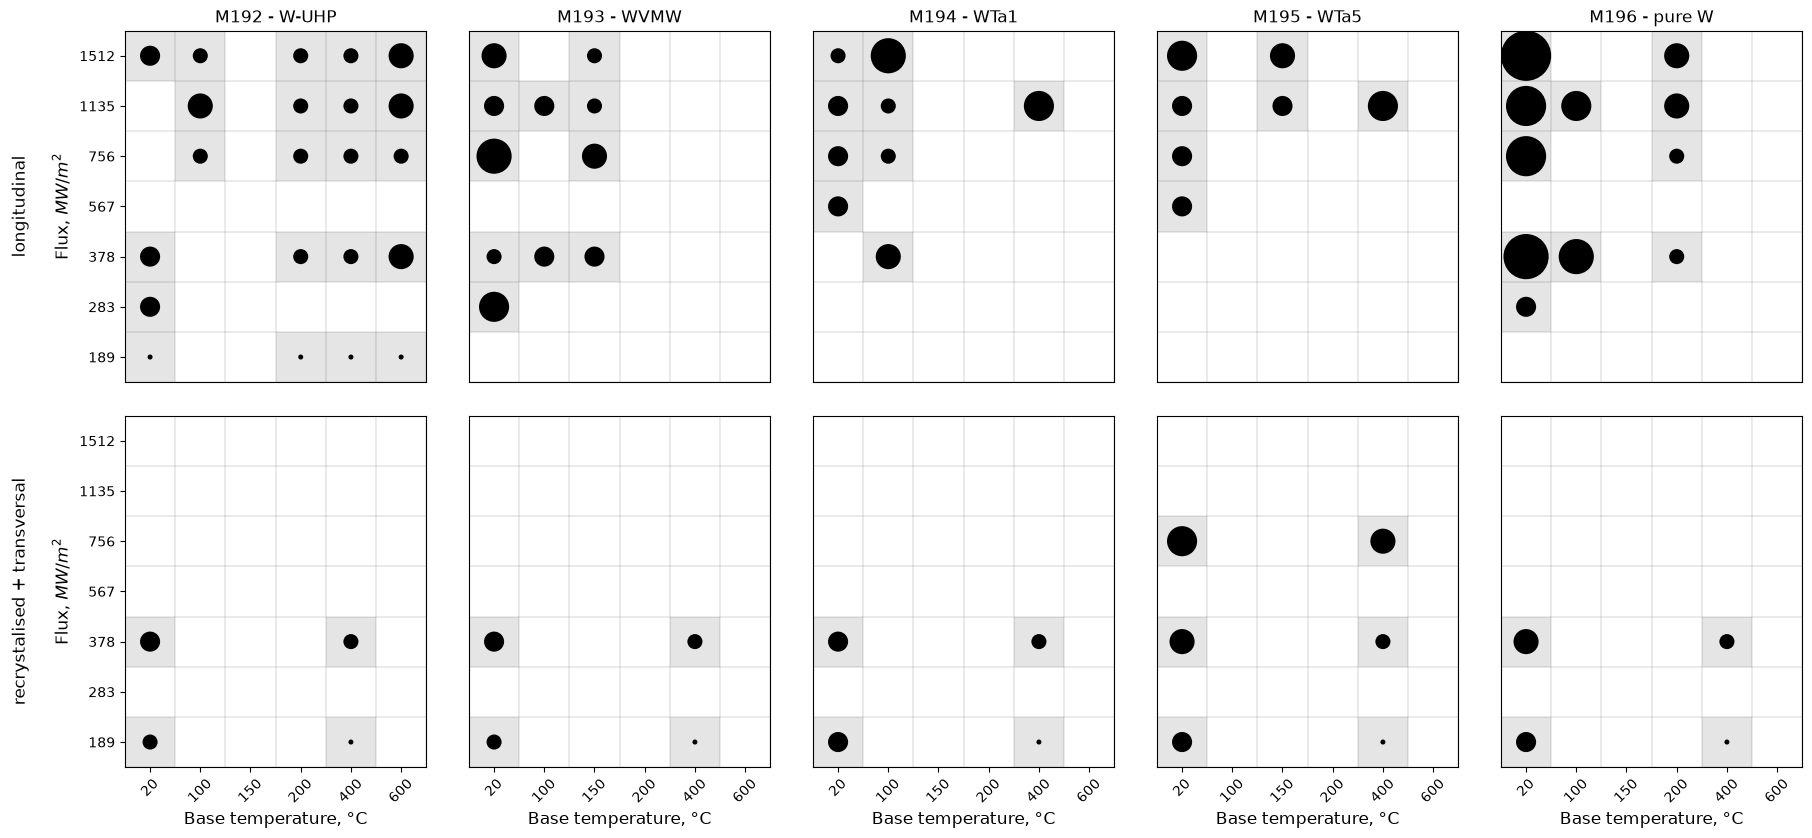

In [12]:
what_to_show = 'circle maps' # 'heatmaps', 'circle maps', 'label'


uniq_fluxes = np.unique(dataset.metadata['flux'])
uniq_base_temps = np.unique(dataset.metadata['base_temp'])
uniq_fluxes = uniq_fluxes[~np.isnan(uniq_fluxes)]
uniq_base_temps = uniq_base_temps[~np.isnan(uniq_base_temps)]

num_imgs = {}
for load_type in dataset.unique_meta['loadtype']:
    for material in dataset.unique_meta['material']:
        for flux in uniq_fluxes:
            for base_temp in uniq_base_temps:
                num_imgs[(load_type, material, flux, base_temp)] = len(dataset.filter_by_metadata(material=material, loadtype=load_type, flux=flux, base_temp=base_temp))
vmin = np.min(list(num_imgs.values()))
vmax = np.max(list(num_imgs.values()))


# plot densities as circle maps in a grid of material vs loadtype
ij = 0
num_cols = len(dataset.unique_meta['material'])
num_rows = len(dataset.unique_meta['loadtype'])-1
fig, axes = plt.subplots(num_rows, num_cols, figsize=(3.5*num_cols, 4*num_rows))
fig.tight_layout(h_pad=0.0, w_pad=0.0)

for axj, (load_type, axrow) in enumerate(zip(dataset.unique_meta['loadtype'][:-1], axes)):
    for axi, (material, ax) in enumerate(zip(dataset.unique_meta['material'], axrow)):
        ij += 1

        nrows, ncols = len(uniq_fluxes), len(uniq_base_temps)

        if what_to_show == 'heatmaps':
            last_im = ax.imshow(dnst, cmap='binary', vmin=vmin, vmax=vmax, origin='lower', aspect='equal')
            # ---- axis labeling using GLOBAL grid ----
            ax.set_xticks(np.arange(len(base_temps)))
            ax.set_xticklabels([f'{t:g}' for t in base_temps], rotation=45)
            ax.set_yticks(np.arange(len(fluxes)))
            ax.set_yticklabels([f'{f:g}' for f in fluxes])

            # Optional pixel grid
            ax.set_xticks(np.arange(-0.5, len(base_temps), 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(fluxes), 1), minor=True)
            ax.grid(which='minor', color='k', linewidth=0.3)
            ax.tick_params(which='minor', bottom=False, left=False)
        elif what_to_show == 'label':
            last_im = ax.imshow(label, cmap='binary', vmin=0, vmax=10, origin='lower', aspect='equal')
            # ---- axis labeling using GLOBAL grid ----
            ax.set_xticks(np.arange(len(base_temps)))
            ax.set_xticklabels([f'{t:g}' for t in base_temps], rotation=45)
            ax.set_yticks(np.arange(len(fluxes)))
            ax.set_yticklabels([f'{f:g}' for f in fluxes])

            # Optional pixel grid
            ax.set_xticks(np.arange(-0.5, len(base_temps), 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(fluxes), 1), minor=True)
            ax.grid(which='minor', color='k', linewidth=0.3)
            ax.tick_params(which='minor', bottom=False, left=False)
        else:
            # Draw white boxes for each cell
            for i, flux in enumerate(uniq_fluxes):
                for j, base_temp in enumerate(uniq_base_temps):
                    val = num_imgs[(load_type, material, flux, base_temp)]

                    if val>0:
                        ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor='gray', alpha=0.2, edgecolor='k', linewidth=0.3))
                    else:
                        ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor='white', alpha=0.2, edgecolor='k', linewidth=0.3))
                        continue

                    # Map value to circle radius
                    # max radius = 0.5 so largest circle fills the box
                    frac = (val - vmin) / (vmax - vmin)
                    frac = np.clip(frac, 0, 1)
                    radius = 0.5 * frac

                    if radius > 0:
                        ax.add_patch(Circle((j, i), radius=radius, facecolor='black', edgecolor='none'))

        if axi == 0:
            if load_type == 'longitudinal':
                ax.set_ylabel(f"{load_type}\n\n"+r"Flux, $MW/m^2$", fontsize=12)
            else:
                ax.set_ylabel(f"recrystalised + transversal\n\n"+r"Flux, $MW/m^2$", fontsize=12)
        if axj == 0:
            ax.set_title(f"{material}", fontsize=12)
        if axj == num_rows - 1:
            ax.set_xlabel(f"Base temperature, °C", fontsize=12)

        if axj == num_rows - 1:
            ax.set_xticks(np.arange(len(uniq_base_temps)))
            ax.set_xticklabels([f'{t:g}' for t in uniq_base_temps], rotation=45)
        else:
            ax.set_xticks([])
        if axi == 0:
            ax.set_yticks(np.arange(len(uniq_fluxes)))
            ax.set_yticklabels([f'{f:g}' for f in uniq_fluxes])
        else:
            ax.set_yticks([])

        # Match cell boundaries exactly
        ax.set_xlim(-0.5, ncols - 0.5)
        ax.set_ylim(-0.5, nrows - 0.5)
        ax.set_aspect('equal')

if what_to_show in ['heatmaps', 'label']:
    # ---------- shared colorbar ----------
    # if last_im is not None:
    cbar = fig.colorbar(last_im, ax=axes, location="right", shrink=1, pad=0.02)
    # cbar.set_label('Crack density')